# Multi-Duration Rainfall Coverage vs Discharge Analysis
This notebook extends the existing 10‑min rainfall coverage analysis to multiple accumulation durations (e.g. 10, 20, 30, 60 minutes).

It scans the `wet_area_summary_*.pkl` files, infers duration & threshold from filenames, merges with the main simulation discharge results, then computes and visualizes R² relationships between mean wet area coverage (area fraction with intensity > threshold) and peak discharge for historical & future scenarios.

## Filename Conventions Assumed
Two patterns are supported:
1. `wet_area_summary_<THRESH>.pkl`  (assumed 10‑min duration; legacy format).
2. `wet_area_summary_<DUR>min_<THRESH>.pkl`  (explicit duration). Example: `wet_area_summary_20min_3.pkl` for 20‑min, 3 mm threshold.

Update or regenerate additional duration files before running if they don't yet exist.

## Outputs
* Per-duration scatter + regression plots (optional).
* R² vs threshold bar/line charts (historical, future, combined).
* Combined multi-duration comparison plot.
* Aggregated R² results DataFrame.

In [11]:
import os, re, math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress
from typing import List, Dict, Tuple

# --- User Parameters ---
sim_dir = 'D:/Development/RESEARCH/Raanana/SWMM/from_radar/Climate_Change'  # base directory
pickles_dir = os.path.join(sim_dir, 'pickles')
main_results_path = os.path.join(pickles_dir, 'Urbanization_comparsion', 'urbanization_1_5.pkl')  # adjust if needed
durations_to_analyze = [10, 20, 30, 60]  # minutes (only those with available files will be processed)
min_points_for_regression = 2  # require at least this many data points per threshold-scenario
scatter_plots_per_duration = True  # set False to skip scatter plots
max_scatter_thresholds = None  # None = all thresholds, or set an int to limit per duration

# --- Load core discharge results ---
final_results_df = pd.read_pickle(main_results_path)
print(f'Loaded main results with shape: {final_results_df.shape}')

Loaded main results with shape: (3444, 96)


In [12]:
import os
import re
import pandas as pd

PATTERN_LEGACY = re.compile(r'^wet_area_summary_([0-9]+(?:[._][0-9]+)?)\.pkl$')              # implicit 10 min
PATTERN_EXPLICIT = re.compile(r'^wet_area_summary_([0-9]+(?:[._][0-9]+)?)min_([0-9]+(?:[._][0-9]+)?)\.pkl$')

MERGE_KEYS = [('event_num', '', ''), ('x', '', ''), ('y', '', ''), ('d', '', '')]
WET_COL_HIST = ('historical', 'spatial_rain', 'wet_area_percent_mean')
WET_COL_FUT  = ('future', 'spatial_rain', 'wet_area_percent_mean')
DISCH_HIST   = ('historical', 'basin discharge', 'max_discharge')
DISCH_FUT    = ('future', 'basin discharge', 'max_discharge')

# Defensive: ensure MultiIndex columns remain MultiIndex after merges later
if not isinstance(final_results_df.columns, pd.MultiIndex):
    final_results_df.columns = pd.MultiIndex.from_tuples(
        [(c, '', '') if isinstance(c, str) else tuple(c) for c in final_results_df.columns]
    )

# Inventory available wet area summary files
files = [f for f in os.listdir(pickles_dir) if f.startswith('wet_area_summary_') and f.endswith('.pkl')]

records = []
for f in files:
    m_explicit = PATTERN_EXPLICIT.match(f)
    if m_explicit:
        dur_s = m_explicit.group(1).replace('_', '.')  # normalize underscore to dot
        thr_s = m_explicit.group(2).replace('_', '.')
        duration_min = float(dur_s)
        threshold_mm = float(thr_s)
        records.append((f, duration_min, threshold_mm))
        continue

    m_legacy = PATTERN_LEGACY.match(f)
    if m_legacy:
        thr_s = m_legacy.group(1).replace('_', '.')
        duration_min = 10.0  # assume 10-min for legacy naming
        threshold_mm = float(thr_s)
        records.append((f, duration_min, threshold_mm))
        continue
    # If neither pattern matched, silently skip or log if you prefer

files_df = pd.DataFrame(records, columns=['filename', 'duration_min', 'threshold_mm'])
if files_df.empty:
    raise FileNotFoundError('No wet_area_summary_*.pkl files found in pickles directory.')

print('Discovered files:')
display(files_df.sort_values(['duration_min', 'threshold_mm']).head(20))

unique_durations_available = sorted(files_df.duration_min.unique())
print('Available durations:', unique_durations_available)

missing = [d for d in durations_to_analyze if d not in unique_durations_available]
if missing:
    print(f'WARNING: These requested durations have no files and will be skipped: {missing}')


Discovered files:


,filename,duration_min,threshold_mm
0,wet_area_summary_1.pkl,10.0,1.0
4,wet_area_summary_2.pkl,10.0,2.0
5,wet_area_summary_3.pkl,10.0,3.0
6,wet_area_summary_5.pkl,10.0,5.0
7,wet_area_summary_6.pkl,10.0,6.0
8,wet_area_summary_7_5.pkl,10.0,7.5
1,wet_area_summary_10.pkl,10.0,10.0
2,wet_area_summary_12_5.pkl,10.0,12.5
3,wet_area_summary_15.pkl,10.0,15.0


Available durations: [10.0]


In [13]:
def load_wet_area_for_duration(duration: int) -> pd.DataFrame:
    subset = files_df[files_df.duration_min == duration]
    if subset.empty:
        return pd.DataFrame()
    dfs = []
    for _, row in subset.iterrows():
        path = os.path.join(pickles_dir, row.filename)
        wet_df = pd.read_pickle(path)
        # Keep only merge keys + wet area columns
        needed_cols = MERGE_KEYS + [WET_COL_HIST, WET_COL_FUT]
        df_small = wet_df[needed_cols].copy()
        # Add threshold, duration metadata columns (simple tuples to avoid MultiIndex complications)
        df_small[('threshold_mm','','')] = row.threshold_mm
        df_small[('duration_min','','')] = duration
        dfs.append(df_small)
    combined = pd.concat(dfs, ignore_index=True)
    # Ensure MultiIndex columns
    if not isinstance(combined.columns, pd.MultiIndex):
        combined.columns = pd.MultiIndex.from_tuples(combined.columns)
    return combined


In [14]:
# Helper functions that were missing
import math, time
from scipy.stats import linregress

def compute_r2(x: pd.Series, y: pd.Series):
    """Return (slope, intercept, r2); NaNs if not enough points."""
    if len(x) < min_points_for_regression or len(y) < min_points_for_regression:
        return math.nan, math.nan, math.nan
    slope, intercept, r, p, stderr = linregress(x, y)
    return slope, intercept, r**2

def analyze_duration(duration: int) -> pd.DataFrame:
    """Merge wet area data for a specific duration with discharge and compute R² across thresholds."""
    wet_df = load_wet_area_for_duration(duration)
    if wet_df.empty:
        print(f'[analyze_duration] No wet area data for duration {duration} min.')
        return pd.DataFrame()

    thresholds = sorted(wet_df[('threshold_mm','', '')].unique())
    results_rows = []
    t0 = time.time()
    for i, thr in enumerate(thresholds, 1):
        wet_thr = wet_df[wet_df[('threshold_mm','', '')] == thr]
        merged = pd.merge(
            final_results_df,
            wet_thr,
            on=MERGE_KEYS,
            how='left'
        )
        # Extract required series
        x_hist = merged[WET_COL_HIST]
        y_hist = merged[DISCH_HIST]
        x_fut  = merged[WET_COL_FUT]
        y_fut  = merged[DISCH_FUT]

        # Masks
        mask_h = (~x_hist.isna()) & (~y_hist.isna())
        mask_f = (~x_fut.isna()) & (~y_fut.isna())
        xh, yh = x_hist[mask_h], y_hist[mask_h]
        xf, yf = x_fut[mask_f], y_fut[mask_f]
        xc = pd.concat([xh, xf])
        yc = pd.concat([yh, yf])

        slope_h, int_h, r2_h = compute_r2(xh, yh)
        slope_f, int_f, r2_f = compute_r2(xf, yf)
        slope_c, int_c, r2_c = compute_r2(xc, yc)

        results_rows.append({
            'duration_min': duration,
            'threshold_mm': thr,
            'n_hist': len(xh),
            'n_fut': len(xf),
            'n_comb': len(xc),
            'slope_hist': slope_h,
            'slope_fut': slope_f,
            'slope_comb': slope_c,
            'r2_hist': r2_h,
            'r2_fut': r2_f,
            'r2_comb': r2_c
        })

        if scatter_plots_per_duration and (max_scatter_thresholds is None or i <= max_scatter_thresholds):
            plt.figure(figsize=(7,5))
            if len(xh):
                plt.scatter(xh, yh, c='tab:blue', alpha=0.7, label=f'Hist (R²={r2_h:.2f})')
                if not math.isnan(slope_h):
                    xs = np.linspace(xh.min(), xh.max(), 50)
                    plt.plot(xs, slope_h*xs+int_h, color='tab:blue')
            if len(xf):
                plt.scatter(xf, yf, c='tab:orange', alpha=0.7, label=f'Fut (R²={r2_f:.2f})')
                if not math.isnan(slope_f):
                    xs = np.linspace(xf.min(), xf.max(), 50)
                    plt.plot(xs, slope_f*xs+int_f, color='tab:orange')
            plt.title(f'Duration {duration} min | Threshold {thr} mm')
            plt.xlabel('Mean Wet Area Percent')
            plt.ylabel('Max Discharge [m³/s]')
            plt.grid(True, ls='--', alpha=0.4)
            plt.legend()
            plt.tight_layout()
            plt.show()

        if i % 5 == 0 or i == len(thresholds):
            elapsed = time.time() - t0
            print(f'  Processed {i}/{len(thresholds)} thresholds for {duration} min (elapsed {elapsed:.1f}s)')

    return pd.DataFrame(results_rows)

print('Helper functions (compute_r2, analyze_duration) defined.')

Helper functions (compute_r2, analyze_duration) defined.


Analyzing duration 10 min...


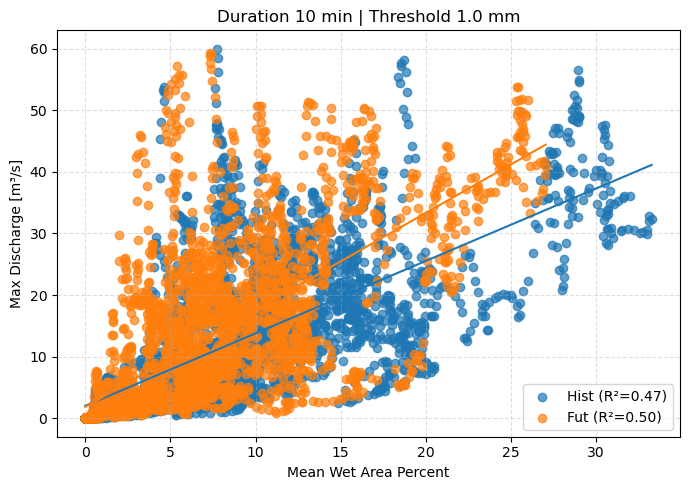

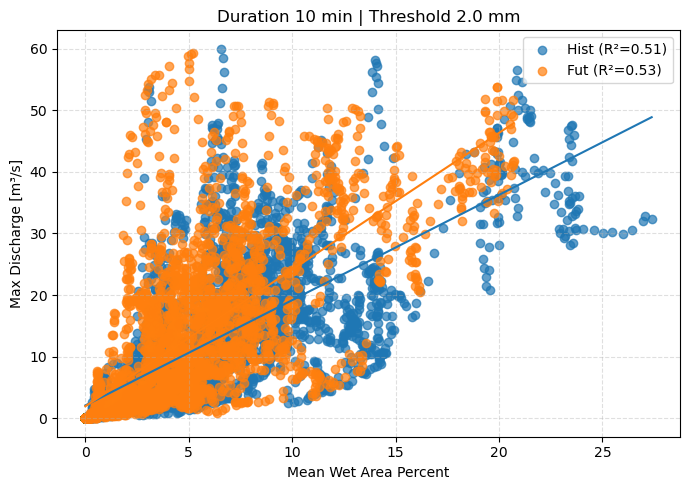

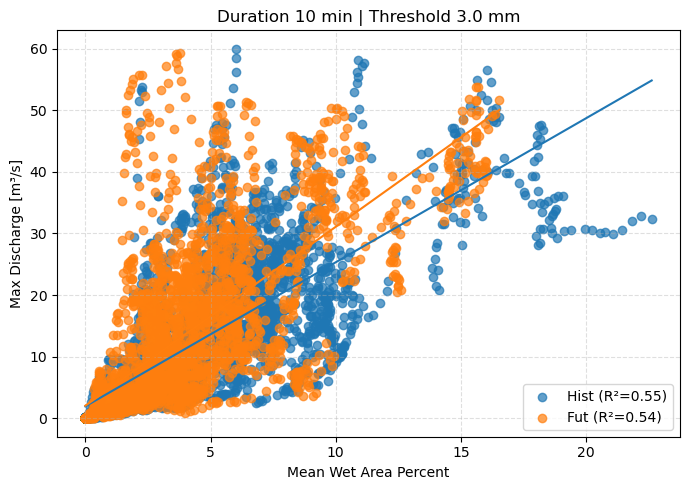

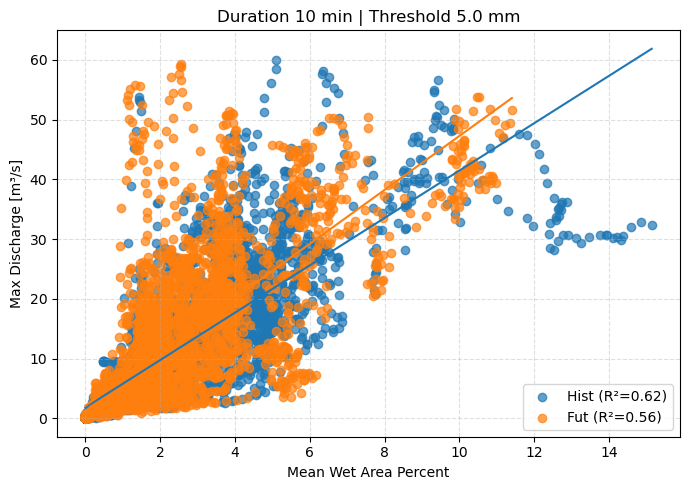

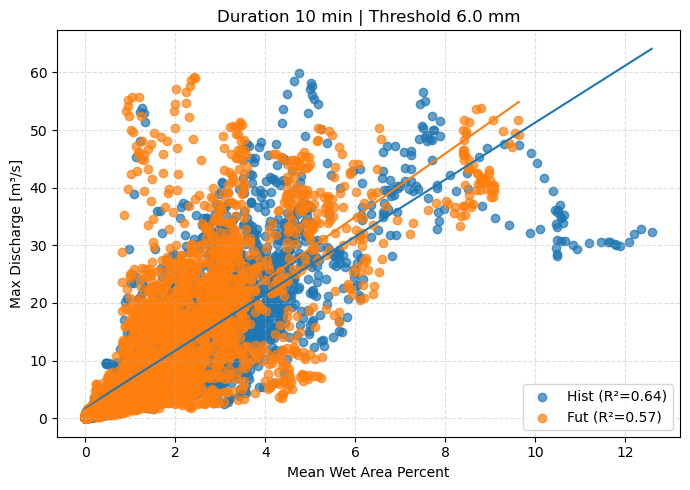

  Processed 5/9 thresholds for 10 min (elapsed 0.9s)


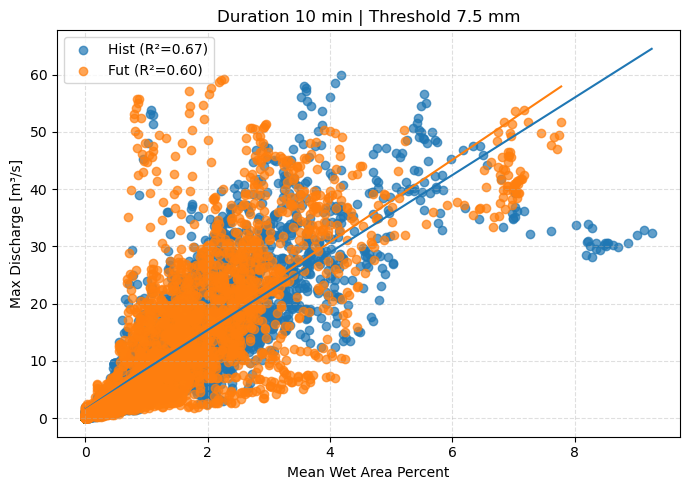

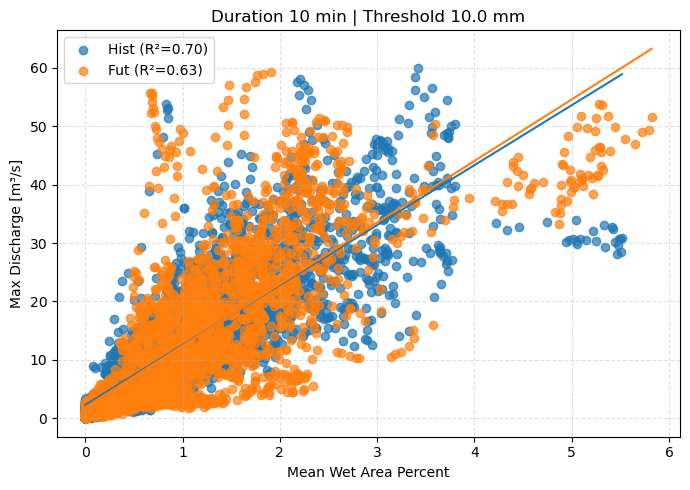

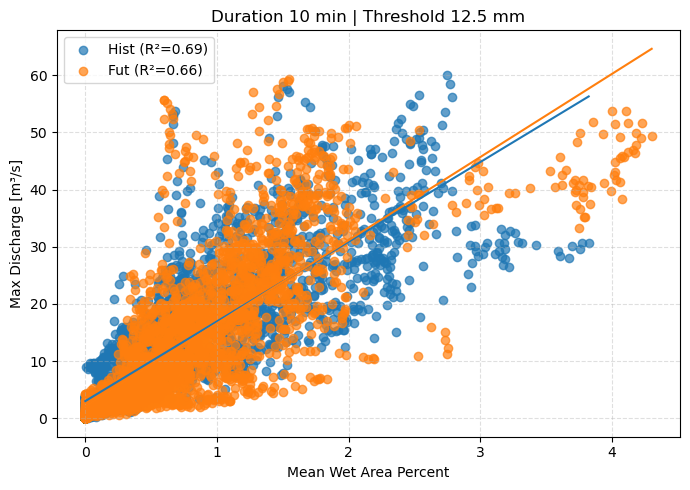

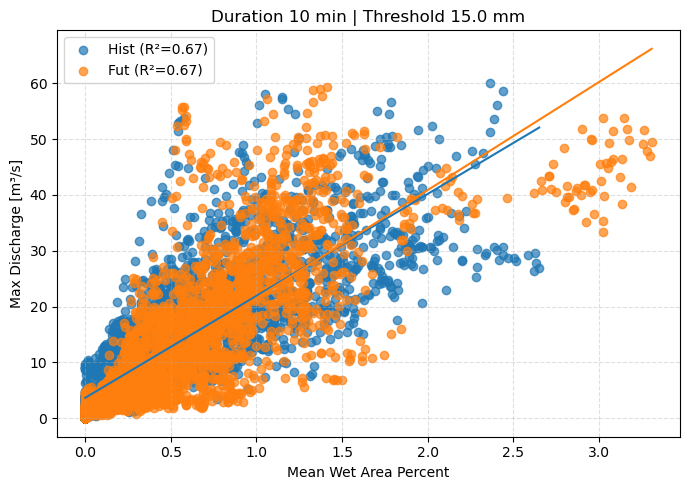

  Processed 9/9 thresholds for 10 min (elapsed 1.5s)
Skipping duration 20 (no files).
Skipping duration 30 (no files).
Skipping duration 60 (no files).
Combined R² results shape: (9, 11)


,duration_min,threshold_mm,n_hist,n_fut,n_comb,slope_hist,slope_fut,slope_comb,r2_hist,r2_fut,r2_comb
0,10,1.0,3321,3321,6642,1.175221,1.574387,1.300990,0.472084,0.498570,0.464842
1,10,2.0,3321,3321,6642,1.708323,2.218597,1.881553,0.508590,0.529127,0.501702
2,10,3.0,3321,3321,6642,2.338616,2.904098,2.535325,0.549625,0.540118,0.530136
3,10,5.0,3321,3321,6642,3.964622,4.516486,4.177345,0.615737,0.559532,0.578610
4,10,6.0,3321,3321,6642,4.945005,5.480668,5.164599,0.637182,0.574073,0.598684


In [15]:
# Run analysis for each requested duration (skip if not available)
all_results = []
for dur in durations_to_analyze:
    if dur not in files_df.duration_min.values:
        print(f'Skipping duration {dur} (no files).')
        continue
    print(f'Analyzing duration {dur} min...')
    res = analyze_duration(dur)
    if not res.empty: all_results.append(res)

if not all_results:
    raise RuntimeError('No duration produced results. Check file availability or parameters.')

results_df = pd.concat(all_results, ignore_index=True)
print('Combined R² results shape:', results_df.shape)
results_df.head()

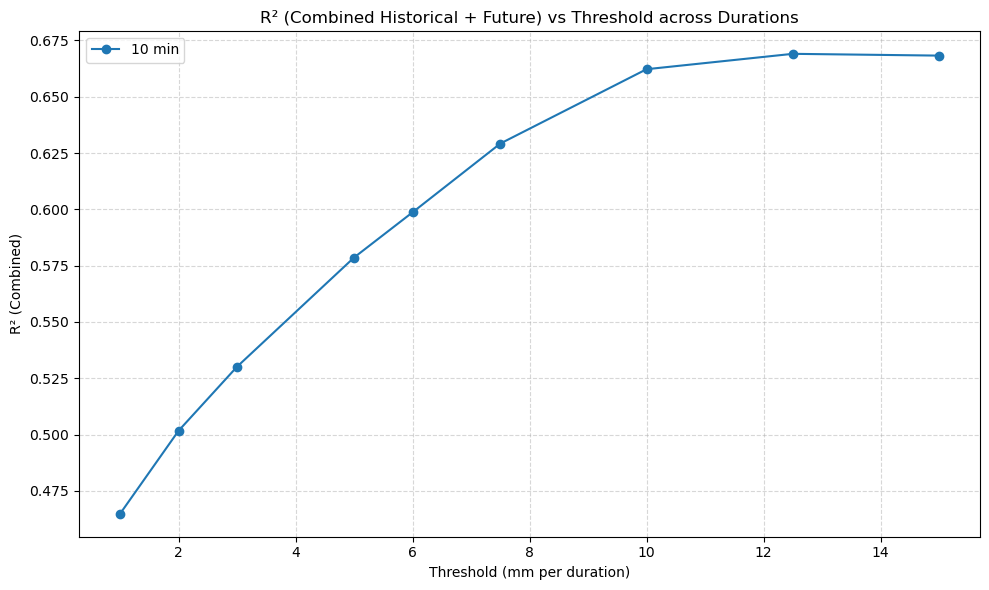

In [16]:
# Plot R² (combined) vs threshold for each duration
plt.figure(figsize=(10,6))
for dur, grp in results_df.groupby('duration_min'):
    plt.plot(grp['threshold_mm'], grp['r2_comb'], marker='o', label=f'{dur} min')
plt.xlabel('Threshold (mm per duration)')
plt.ylabel('R² (Combined)')
plt.title('R² (Combined Historical + Future) vs Threshold across Durations')
plt.grid(True, ls='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

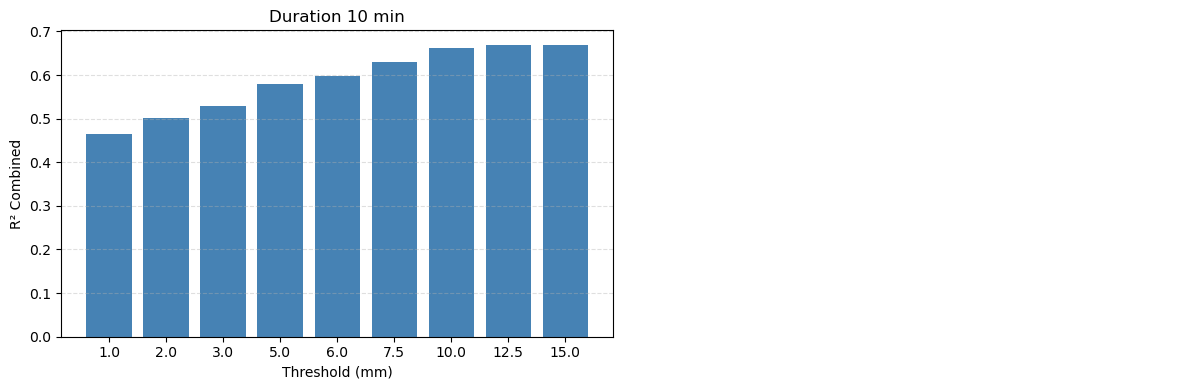

In [17]:
# Bar charts per duration (combined R²)
fig, axes = plt.subplots(nrows=math.ceil(len(results_df.duration_min.unique())/2), ncols=2, figsize=(12, 4*math.ceil(len(results_df.duration_min.unique())/2)))
axes = axes.flatten()
for ax, (dur, grp) in zip(axes, results_df.groupby('duration_min')):
    ax.bar(grp['threshold_mm'].astype(str), grp['r2_comb'], color='steelblue')
    ax.set_title(f'Duration {dur} min')
    ax.set_xlabel('Threshold (mm)')
    ax.set_ylabel('R² Combined')
    ax.grid(axis='y', ls='--', alpha=0.4)
for ax in axes[len(results_df.duration_min.unique()):]:
    ax.axis('off')
plt.tight_layout()
plt.show()

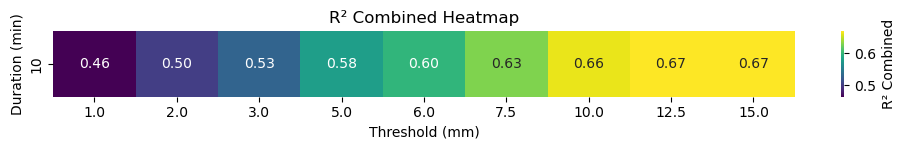

In [18]:
# Optional: Heatmap of R² combined (duration x threshold)
# Pivot to matrix
heat_df = results_df.pivot(index='duration_min', columns='threshold_mm', values='r2_comb')
plt.figure(figsize=(min(14, 1+heat_df.shape[1]), 1+0.6*heat_df.shape[0]))
import seaborn as sns
if not heat_df.empty:
    sns.heatmap(heat_df, annot=True, fmt='.2f', cmap='viridis', cbar_kws={'label':'R² Combined'})
    plt.title('R² Combined Heatmap')
    plt.xlabel('Threshold (mm)')
    plt.ylabel('Duration (min)')
    plt.tight_layout()
    plt.show()
else:
    print('Heatmap skipped (empty).')

In [19]:
# Save results for downstream use
out_path = os.path.join(pickles_dir, 'multi_duration_wet_area_r2.pkl')
results_df.to_pickle(out_path)
print('Saved aggregated R² results to:', out_path)
results_df.describe(include='all')

Saved aggregated R² results to: D:/Development/RESEARCH/Raanana/SWMM/from_radar/Climate_Change\pickles\multi_duration_wet_area_r2.pkl


,duration_min,threshold_mm,n_hist,n_fut,n_comb,slope_hist,slope_fut,slope_comb,r2_hist,r2_fut,r2_comb
count,9.0,9.000000,9.0,9.0,9.0,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000
mean,10.0,6.888889,3321.0,3321.0,6642.0,7.038646,7.590336,7.275375,0.611137,0.584877,0.589190
std,0.0,4.813898,0.0,0.0,0.0,5.940900,6.082919,6.047652,0.081750,0.059969,0.076133
min,10.0,1.000000,3321.0,3321.0,6642.0,1.175221,1.574387,1.300990,0.472084,0.498570,0.464842
25%,10.0,3.000000,3321.0,3321.0,6642.0,2.338616,2.904098,2.535325,0.549625,0.540118,0.530136
50%,10.0,6.000000,3321.0,3321.0,6642.0,4.945005,5.480668,5.164599,0.637182,0.574073,0.598684
75%,10.0,10.000000,3321.0,3321.0,6642.0,10.265017,10.541473,10.407985,0.668395,0.634586,0.662220
max,10.0,15.000000,3321.0,3321.0,6642.0,18.240266,19.329368,18.791572,0.695600,0.672444,0.669049


### Notes / Next Steps
* If you need different thresholds per duration, regenerate the wet area summary pickles with appropriate logic.
* You can extend `analyze_duration` to compute alternative metrics (median wet area, max, etc.).
* Integrate uncertainty (confidence intervals) by bootstrapping events if desired.